# Forecasting and Scenario Generation -- Methodology Visuals

Two methodology figures adapted from `5_scenario_gen/copula_testing_neat_final.ipynb`,
regenerated here standalone (same model, same 2018 training-year windows, same frozen
copula draws):

1. **Representative week per season -- forecast vs realised** (Section 3.1): for each
   meteorological season, the Monday-Sunday week whose median forecast sits closest to
   that season's own median, plotted as the nested quantile fan against the realised
   trajectory -- a sanity check that the marginals look sensible across the year.
2. **Representative day per season -- forecast vs scenarios** (Section 7.2): for each
   season, the single day whose total realised prosumption sits closest to that season's
   median, shown two ways side by side -- the quantile forecast fan (left) and the actual
   copula-generated scenario paths for that same day (right).

## Setup

In [51]:
from __future__ import annotations
import sys
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyprojroot import here

ROOT_DIR = here()
FORECASTING_DIR = ROOT_DIR / "4_forecasting"
COPULA_DIR = ROOT_DIR / "5_scenario_gen"
DATA_DIR = ROOT_DIR / "1_data" / "processed"

sys.path.insert(0, str(FORECASTING_DIR))
sys.path.insert(0, str(COPULA_DIR))

from forecasting import (
    QUANTILE_LEVELS, HIST_COLS, FEAT_COLS, EXO_COLS, TRAIN_START, VAL_START,
    build_features, reindex_and_impute, make_windows,
    normalise_hist, normalise_exo, denormalise_y, Baseline_Forecaster,
)
from copula_lib import FrozenCopulaSampler

device = torch.device("cpu")
print(f"training-year window: {TRAIN_START} -> {VAL_START}")

training-year window: 2018-01-01 00:00:00+00:00 -> 2019-01-01 00:00:00+00:00


### Load data, the frozen baseline forecaster, and 2018 training-year forecasts

Same reconstruction and gate-aligned window scheme as the original notebook's Sections
2-3 (`gate_aligned_only=True, issue_hour=9`, one window per delivery day, full 2018
training year).

In [52]:
base_data = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"]).set_index("datetime")
base_data = reindex_and_impute(base_data, HIST_COLS, freq="1h", warn_gap=6)
frame_full = build_features(base_data, feature_cols=FEAT_COLS)

forecaster_checkpoint = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = forecaster_checkpoint["scaler_stats"]

model = Baseline_Forecaster(**forecaster_checkpoint["model_config"])
model.load_state_dict(forecaster_checkpoint["state_dict"])
model = model.to(device).eval()

h = pd.Timedelta(hours=1)
copula_windows = make_windows(
    frame_full, y_range=(TRAIN_START, VAL_START - h),
    gate_aligned_only=True, issue_hour=9,
    exo_cols=EXO_COLS, hist_cols=HIST_COLS, target_col="prosumption",
)
n_days = len(copula_windows.delivery_start)
deliv_start, deliv_end = copula_windows.ds, copula_windows.de
print(f"n_days={n_days}  deliv_start={deliv_start}  deliv_end={deliv_end}")


def forecast_quantiles(x_hist_day, x_fut_day):
    with torch.no_grad():
        xh = torch.as_tensor(normalise_hist(np.asarray(x_hist_day), sc), dtype=torch.float32, device=device).unsqueeze(0)
        xf = torch.as_tensor(normalise_exo(np.asarray(x_fut_day), sc), dtype=torch.float32, device=device).unsqueeze(0)
        q_norm = model(xh, xf)
        q_phys = denormalise_y(q_norm, sc)
    return q_phys.squeeze(0).cpu().numpy()   # (24, 19)


q_mw = np.stack([
    forecast_quantiles(copula_windows.x_hist[d], copula_windows.x_fut[d])
    for d in range(n_days)
], axis=0)   # (N, 24, 19)
y = np.asarray(copula_windows.y, dtype=float)   # (N, 24) -- per-day realised
quantiles = q_mw   # (N, 24, 19) -- alias matching the original notebook's naming

mid = len(QUANTILE_LEVELS) // 2
qp = q_mw.reshape(-1, 19)          # (N*24, 19) -- flattened across the whole window set
Yva = y.flatten()                  # (N*24,)
time_idx = pd.date_range(start=deliv_start, end=deliv_end, freq="1h")
print(f"qp.shape={qp.shape}  Yva.shape={Yva.shape}  time_idx spans {len(time_idx)} hours")

[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
n_days=365  deliv_start=2018-01-01 00:00:00+00:00  deliv_end=2018-12-31 23:00:00+00:00
qp.shape=(8760, 19)  Yva.shape=(8760,)  time_idx spans 8760 hours


### Load the frozen copula draws

`Z_corr` -- the frozen correlated Sobol draws -- comes straight from
`frozen_copula.pkl` (the actual artefact used live in training/evaluation), not
recomputed, so the scenarios shown below are exactly what the rest of the project
uses.

In [53]:
cop_bundle = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
Z_corr = cop_bundle["Z_corr"]
sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS).to(device)
print(f"Z_corr.shape={Z_corr.shape}  n_scenarios={Z_corr.shape[0]}")

Z_corr.shape=(64, 24)  n_scenarios=64


## 1. Representative week per season -- forecast vs realised

For each season, the Monday-Sunday week whose median forecast is closest to the
seasonal median, plotted as the nested quantile fan against realised -- reused verbatim
from the original notebook's Section 3.1.

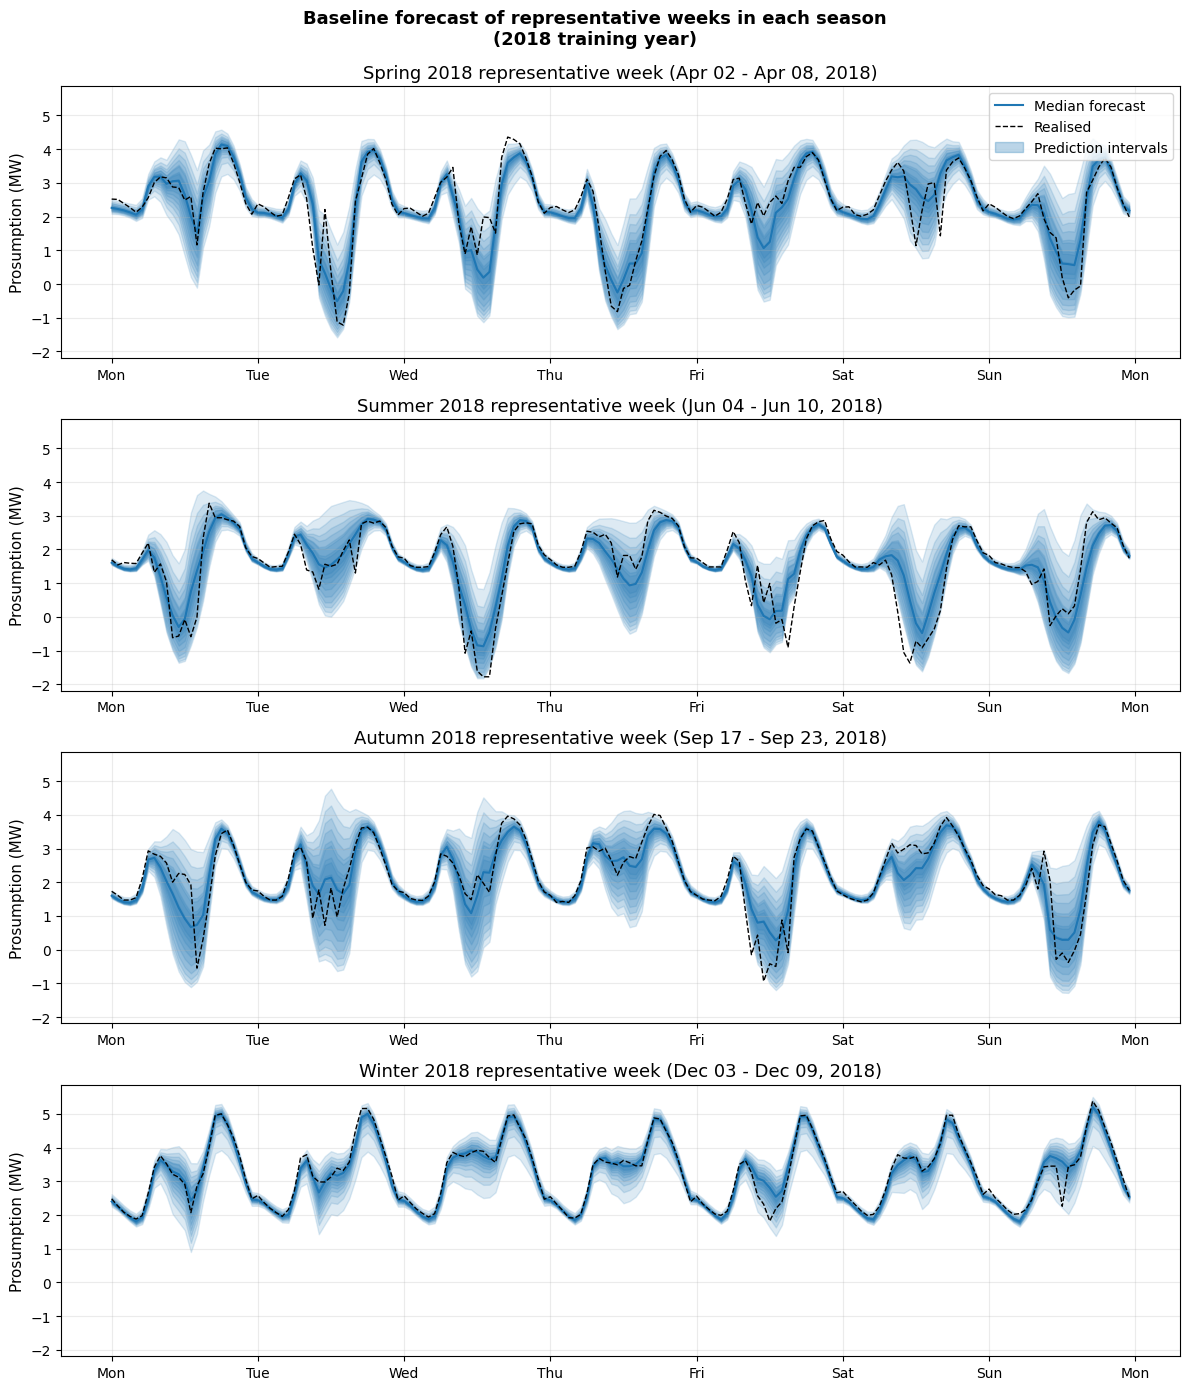

In [54]:
window = 7 * 24  # hours per week

season_map = {
    "Spring 2018": [3, 4, 5],
    "Summer 2018": [6, 7, 8],
    "Autumn 2018": [9, 10, 11],
    "Winter 2018": [12, 1, 2],
}

representative_weeks = []

for season_name, months in season_map.items():
    mask = time_idx.month.isin(months)
    t = time_idx[mask]
    y_season = Yva[mask]
    qp_season = qp[mask, :]

    seasonal_median = np.median(qp_season[:, mid])

    # Force week starts to be Mondays and full weeks to end on Sundays
    season_anchor = t[0].normalize() - pd.to_timedelta(t[0].weekday(), unit="D")
    week_starts = pd.date_range(start=season_anchor, end=t[-1].normalize(), freq="W-MON")

    best_score = np.inf
    best_week_idx = None
    best_week_start = None

    for week_start in week_starts:
        week_end = week_start + pd.Timedelta(days=7)
        week_mask = (t >= week_start) & (t < week_end)
        week_idx = np.flatnonzero(week_mask)

        if len(week_idx) != window:
            continue

        week_qp = qp_season[week_idx, mid]
        score = np.mean(np.abs(week_qp - seasonal_median))

        if score < best_score:
            best_score = score
            best_week_idx = week_idx
            best_week_start = week_start

    if best_week_idx is None:
        raise ValueError(f"No full Monday-Sunday representative week found for {season_name}")

    t_week = t[best_week_idx]
    y_week = y_season[best_week_idx]
    qp_week = qp_season[best_week_idx, :]

    week_end = best_week_start + pd.Timedelta(days=6, hours=23)
    representative_weeks.append((season_name, t_week, y_week, qp_week, best_week_start, week_end))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# 1. UPDATED: Added sharey=True so all 4 seasons use the exact same Y-axis scale
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=False, sharey=True)
fig.subplots_adjust(hspace=0.4)

for ax, (season_name, t_week, y_week, qp_week, week_start, week_end) in zip(axes, representative_weeks):
    for k in range(mid):
        ax.fill_between(t_week, qp_week[:, k], qp_week[:, -1 - k], alpha=0.15, color="C0")

    # 2. UPDATED: Standard sentence casing for labels
    ax.plot(t_week, qp_week[:, mid], color="C0", linewidth=1.5, label="Median forecast")
    ax.plot(t_week, y_week, "k--", linewidth=1.0, label="Realised")

    # 3. UPDATED: Moved exact dates to the title and removed the informal dashes
    date_str = f"{week_start.strftime('%b %d')} - {week_end.strftime('%b %d, %Y')}"
    ax.set_title(f"{season_name.capitalize()} representative week ({date_str})", fontsize=13)
    
    ax.set_ylabel("Prosumption (MW)", fontsize=11)
    ax.grid(alpha=0.25)
    
    # 4. UPDATED: Set X-axis to show abbreviated days of the week (e.g., Mon, Tue)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a'))
    
    # 5. UPDATED: Removed the bulky xlabel entirely since the days of the week are self-explanatory

# 6. UPDATED: Created a custom legend patch to explain the blue shaded bands
handles, labels = axes[0].get_legend_handles_labels()
interval_patch = Patch(color="C0", alpha=0.3, label="Prediction intervals")
handles.append(interval_patch)
labels.append("Prediction intervals")

# Placed the updated legend on the top plot
axes[0].legend(handles=handles, labels=labels, loc="upper right", fontsize=10)

fig.suptitle(
    "Baseline forecast of representative weeks in each season\n"
    "(2018 training year)", 
    fontsize=13, fontweight="bold", y=0.99
)
plt.tight_layout()
plt.show()

## 2. Representative day per season -- forecast vs scenarios

For each season, the single day whose total realised prosumption is closest to that
season's median, shown as the quantile forecast fan (left) and the copula-generated
scenario paths for the same day (right) -- reused verbatim from the original notebook's
Section 7.2. Delivery dates are taken from the actual window range
(`deliv_start`/`deliv_end`), not an assumed Jan-1 start, so season labels stay correct
even if any days were dropped.

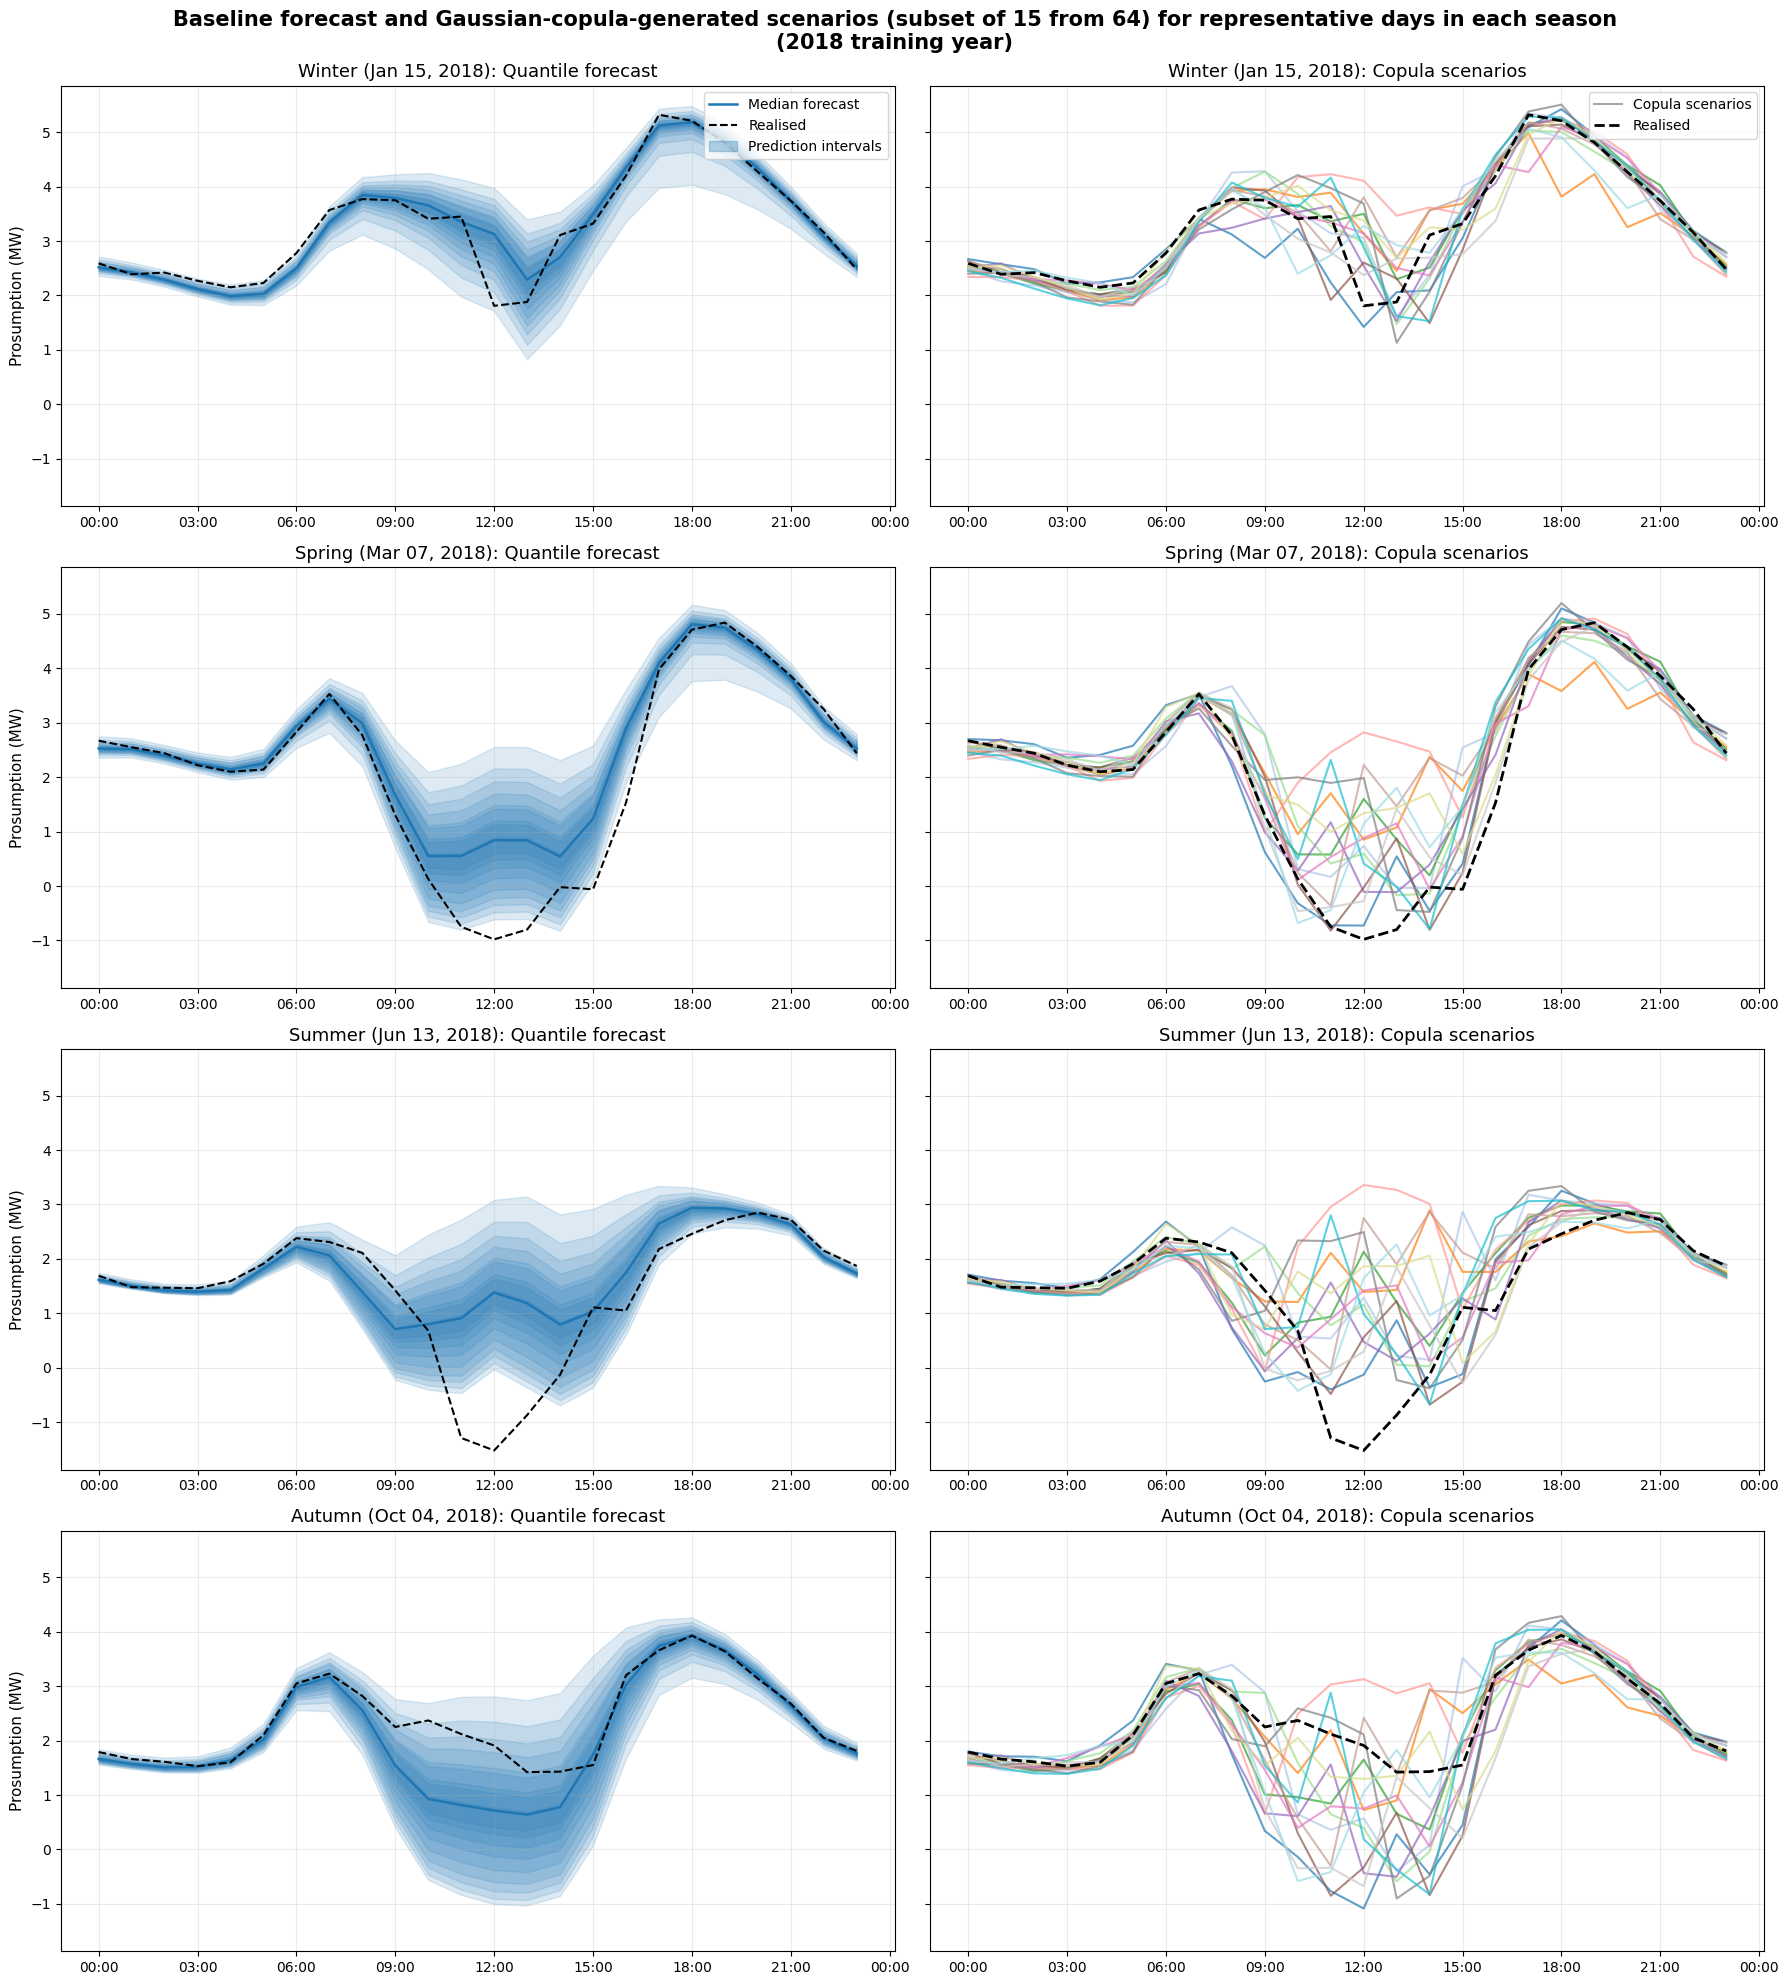

In [55]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_map_day = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
}

data_start_day = pd.Timestamp(deliv_start).normalize()
data_end_day = pd.Timestamp(deliv_end).normalize()

days = pd.date_range(start=data_start_day, end=data_end_day, freq="D")
assert len(days) == y.shape[0], (
    f"Expected {y.shape[0]} daily rows from {data_start_day} to {data_end_day}, "
    f"got {len(days)} dates instead."
)

season_idx = {}
for season, months in season_map_day.items():
    mask = days.month.isin(months)
    day_candidates = np.flatnonzero(mask)
    daily_totals = y[day_candidates].sum(axis=1)
    med_total = np.median(daily_totals)
    best_day = day_candidates[np.argmin(np.abs(daily_totals - med_total))]
    season_idx[season] = int(best_day)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import torch

# 1. UPDATED: Added sharey=True so all 8 panels share the exact same vertical scale
fig, axes = plt.subplots(4, 2, figsize=(18, 20), sharex=False, sharey=True)
fig.subplots_adjust(hspace=0.35, wspace=0.1)

for row, season in enumerate(season_order):
    idx = season_idx[season]
    day_slice = slice(idx * 24, (idx + 1) * 24)

    time_axis = time_idx[day_slice]
    qp_day = qp[day_slice, :]
    y_day = y[idx]
    q_day = quantiles[idx, :, :]

    # Extract the exact date dynamically to place in the title
    date_str = time_axis[0].strftime('%b %d, %Y')

    # --- Left Column: Quantile Forecast ---
    ax_fc = axes[row, 0]
    for k in range(mid):
        ax_fc.fill_between(time_axis, qp_day[:, k], qp_day[:, -1 - k], alpha=0.15, color="C0")
    
    # Standard sentence casing
    ax_fc.plot(time_axis, qp_day[:, mid], color="C0", linewidth=1.8, label="Median forecast")
    ax_fc.plot(time_axis, y_day, "k--", linewidth=1.5, label="Realised")
    
    # 2. UPDATED: Clean academic title, moving the date here instead of the x-axis
    ax_fc.set_title(f"{season.capitalize()} ({date_str}): Quantile forecast", fontsize=13)
    ax_fc.set_ylabel("Prosumption (MW)", fontsize=11)
    ax_fc.grid(alpha=0.25)
    
    # 3. UPDATED: Format X-axis to just show hours (e.g., 06:00, 12:00) without rotation
    ax_fc.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_fc.tick_params(axis="x", rotation=0)

    # 4. UPDATED: Added custom legend patch for the prediction intervals (placed on top row only)
    if row == 0:
        handles, labels = ax_fc.get_legend_handles_labels()
        interval_patch = Patch(color="C0", alpha=0.3, label="Prediction intervals")
        handles.append(interval_patch)
        labels.append("Prediction intervals")
        ax_fc.legend(handles=handles, labels=labels, loc="upper right", fontsize=10)

    # --- Right Column: Copula Scenarios ---
    ax_sc = axes[row, 1]
    quantiles_t = torch.as_tensor(q_day, dtype=torch.float32, device=device)
    scenarios = sampler.prosumption(quantiles_t).detach().cpu().numpy()

    n_plot = min(15, scenarios.shape[0])
    colors = plt.cm.tab20(np.linspace(0, 1, n_plot))

    for i in range(n_plot):
        ax_sc.plot(time_axis, scenarios[i], linewidth=1.5, alpha=0.7, color=colors[i])

    # Brought the realised line to the front using zorder
    ax_sc.plot(time_axis, y_day, "k--", linewidth=2, label="Realised", zorder=3)
    
    ax_sc.set_title(f"{season.capitalize()} ({date_str}): Copula scenarios", fontsize=13)
    ax_sc.grid(alpha=0.25)
    
    ax_sc.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_sc.tick_params(axis="x", rotation=0)

    # 5. UPDATED: Created a clear legend for the spaghetti lines (placed on top row only)
    if row == 0:
        scen_line = Line2D([0], [0], color="grey", linewidth=1.5, alpha=0.7, label="Copula scenarios")
        realised_line = Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Realised")
        ax_sc.legend(handles=[scen_line, realised_line], loc="upper right", fontsize=10)

# 6. UPDATED: Removed the redundant 'time' labels
fig.suptitle(
    "Baseline forecast and Gaussian-copula-generated scenarios (subset of 15 from 64) for representative days in each season\n"
    "(2018 training year)", 
    fontsize=15, fontweight="bold", y=0.99
)
plt.tight_layout()
plt.show()

## 3. Representative day per season -- expected prosumption (`pl_hat`) vs deviation scenarios (`xi`)

Same representative days and same `FrozenCopulaSampler`, but through `mean_and_errors`
instead of `prosumption` -- the exact anchor/error decomposition the DFL objective
itself uses (`p_hat = mean(scenarios)`, `xi = scenarios - p_hat`, zero sample mean by
construction). Left: `pl_hat` against realised, shaded by +/-1 std of `xi` across
scenarios at each hour (the copula's own post-sampling dispersion, not the marginal
quantile bands from Section 2). Right: the 64 `xi` deviation paths themselves, with the
realised deviation from `pl_hat` (`y - pl_hat`) overlaid as a reference -- isolates the
stochastic/correlated deviation structure with the deterministic diurnal shape removed.

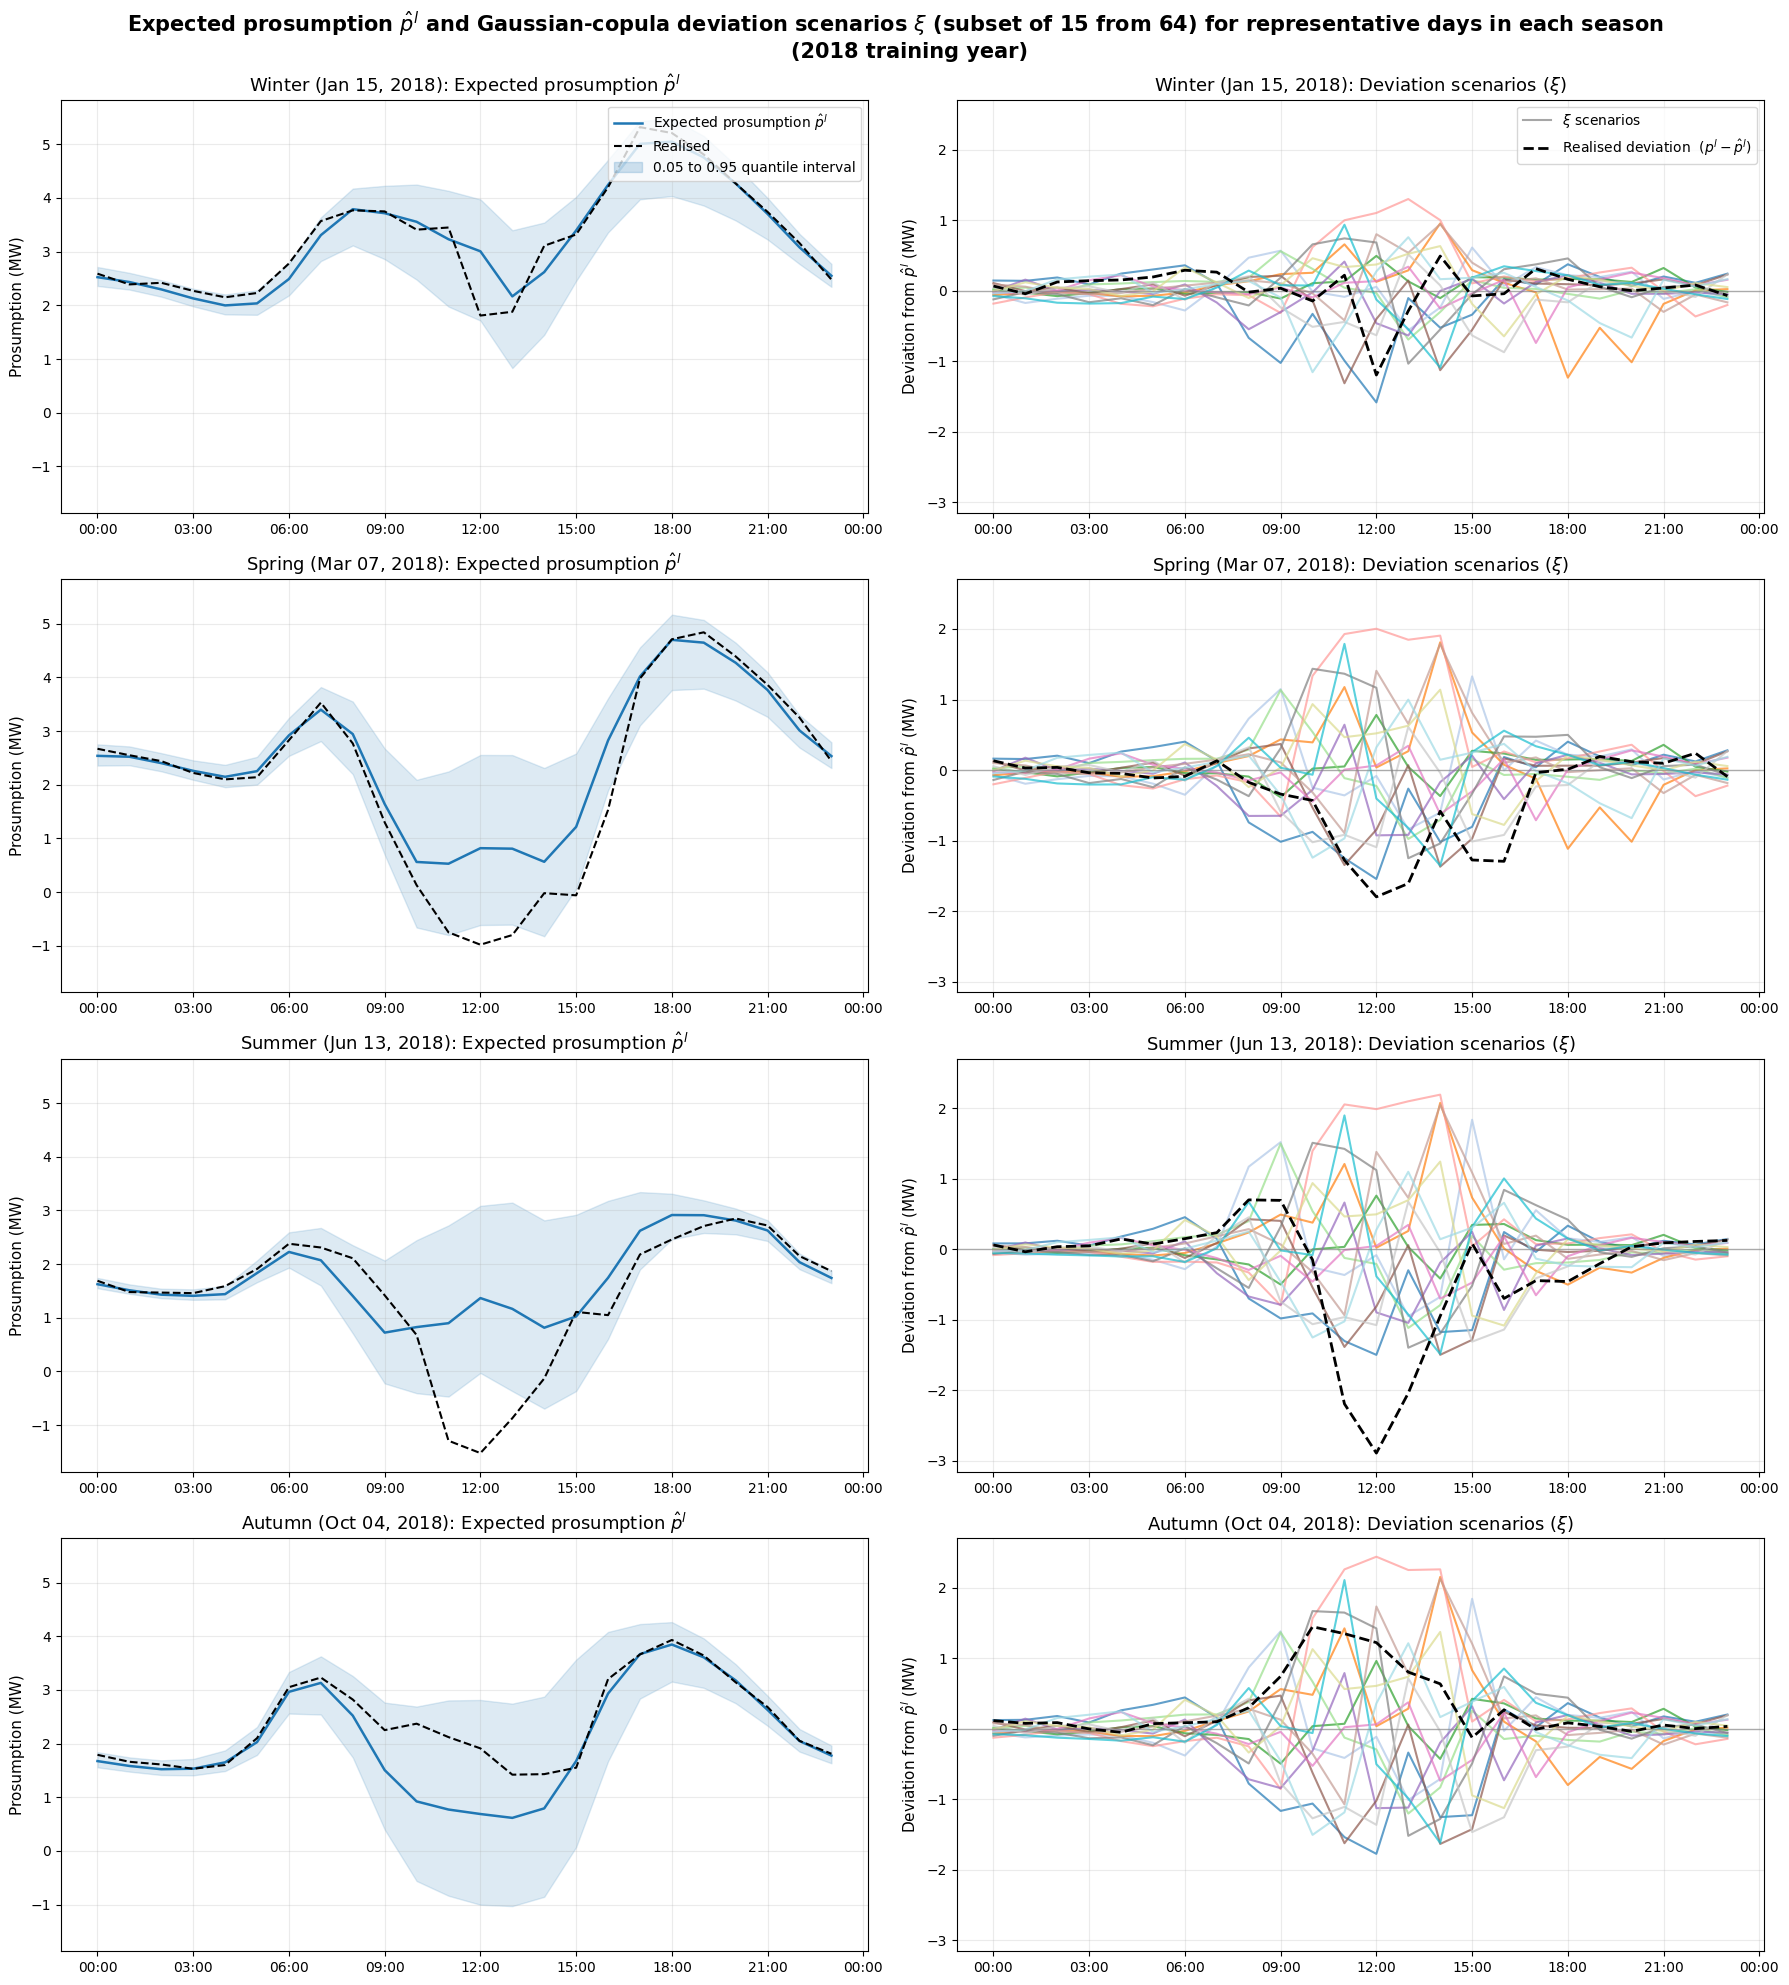

In [57]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, axes = plt.subplots(4, 2, figsize=(18, 20), sharex=False, sharey="col")
fig.subplots_adjust(hspace=0.35, wspace=0.12)

for row, season in enumerate(season_order):
    idx = season_idx[season]
    day_slice = slice(idx * 24, (idx + 1) * 24)

    time_axis = time_idx[day_slice]
    y_day = y[idx]
    q_day = quantiles[idx, :, :]
    qp_day = qp[day_slice, :]
    date_str = time_axis[0].strftime('%b %d, %Y')

    quantiles_t = torch.as_tensor(q_day, dtype=torch.float32, device=device)
    pl_hat, xi_samples = sampler.mean_and_errors(quantiles_t)
    pl_hat = pl_hat.detach().cpu().numpy()               # (24,)
    xi_samples = xi_samples.detach().cpu().numpy()       # (64, 24)
    xi_std = xi_samples.std(axis=0)                       # (24,)

    # --- Left column: expected prosumption (pl_hat) ---
    ax_pl = axes[row, 0]

    ax_pl.fill_between(time_axis, qp_day[:, 0], qp_day[:, -1], alpha=0.15, color="C0")
    #ax_pl.fill_between(time_axis, pl_hat - xi_std, pl_hat + xi_std, alpha=0.2, color="C0")
    ax_pl.plot(time_axis, pl_hat, color="C0", linewidth=1.8, label=r"Expected prosumption $\hat{{p}}^l$")
    ax_pl.plot(time_axis, y_day, "k--", linewidth=1.5, label="Realised")

    ax_pl.set_title(fr"{season.capitalize()} ({date_str}): Expected prosumption $\hat{{p}}^l$", fontsize=13)
    ax_pl.set_ylabel("Prosumption (MW)", fontsize=11)
    ax_pl.grid(alpha=0.25)
    ax_pl.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_pl.tick_params(axis="x", rotation=0)

    if row == 0:
        handles, labels = ax_pl.get_legend_handles_labels()
        band_patch = Patch(color="C0", alpha=0.2, label="0.05 to 0.95 quantile interval")
        handles.append(band_patch)
        labels.append("0.05 to 0.95 quantile interval")
        ax_pl.legend(handles=handles, labels=labels, loc="upper right", fontsize=10)

    # --- Right column: xi deviation scenarios ---
    ax_xi = axes[row, 1]
    n_plot = min(15,xi_samples.shape[0])
    colors = plt.cm.tab20(np.linspace(0, 1, n_plot))
    for i in range(n_plot):
        ax_xi.plot(time_axis, xi_samples[i], linewidth=1.5, alpha=0.7, color=colors[i])

    ax_xi.plot(time_axis, y_day - pl_hat, "k--", linewidth=2, label=r"Realised deviation  $(p^l - \hat{p}^l)$", zorder=3)
    ax_xi.axhline(0, color="grey", linewidth=1, alpha=0.6, zorder=2)

    ax_xi.set_title(fr"{season.capitalize()} ({date_str}): Deviation scenarios $(\xi)$", fontsize=13)
    ax_xi.set_ylabel(r"Deviation from $\hat{{p}}^l$ (MW)", fontsize=11)
    ax_xi.grid(alpha=0.25)
    ax_xi.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_xi.tick_params(axis="x", rotation=0)

    if row == 0:
        xi_line = Line2D([0], [0], color="grey", linewidth=1.5, alpha=0.7, label=r"$\xi$ scenarios")
        realised_line = Line2D([0], [0], color="black", linestyle="--", linewidth=2, label=r"Realised deviation  $(p^l - \hat{p}^l)$")
        ax_xi.legend(handles=[xi_line, realised_line], loc="upper right", fontsize=10)

fig.suptitle(
    r"""Expected prosumption $\hat{p}^l$ and Gaussian-copula deviation scenarios $\xi$ (subset of 15 from 64) for representative days in each season
    (2018 training year)""",
    fontsize=15, fontweight="bold", y=0.99
)
plt.tight_layout()
plt.show()